# **Menyiapkan Semua Library dan Package yang dibutuhkan**

In [1]:
#Memanggil Github Indolu dimana didalamnya banyak repositoory untuk pengolahan
!git clone https://github.com/IndoNLP/indonlu.git

fatal: destination path 'indonlu' already exists and is not an empty directory.


In [2]:
# Install
!pip install emoji # untuk membaca emoji yg akan di gunakan di bagian cleaning
!pip install transformers  # Untuk menggunakan model NLP pretrained seperti IndoBERT
!pip install wordcloud # untuk membuat visualisasi wordcloud
!pip install matplotlib  # untuk membuat plot data
!pip install pandas # untuk membaca dataset
!pip install openpyxla #untuk membaca atau menulis file excel
!pip install vaderSentiment #untuk memakai vader

ERROR: Could not find a version that satisfies the requirement openpyxla (from versions: none)
ERROR: No matching distribution found for openpyxla


In [3]:
# Import Library atau Packages

# Data handling
import pandas as pd                      # Untuk manipulasi dan analisis data tabular (DataFrame)
import numpy as np                       # Untuk operasi numerik dan array

# Regular Expression (dipakai di bagian cleaning)
import re   # Untuk operasi pencocokan dan manipulasi string menggunakan regex

# Utilities (dipakai di bagian train)
from collections import defaultdict, Counter   # defaultdict untuk dict dengan default value, Counter untuk menghitung frekuensi item

# Sklearn utilities
from sklearn.model_selection import train_test_split   # Untuk membagi dataset ke train/test/validasi
from sklearn.metrics import confusion_matrix, classification_report  # Untuk evaluasi performa model
from sklearn.utils import shuffle                      # Untuk mengacak data pada saat proses pelatihann data train

# Natural Language Processing (NLP) (dipakai di bagian cleaning)
import nltk                                # Library NLP digunakan di cleaning 
nltk.download('punkt')                     # Download resource tokenizer NLTK
from nltk.probability import FreqDist      # Untuk menghitung frekuensi kata
from nltk.tokenize import word_tokenize    # Untuk memecah teks menjadi token kata
import emoji                               # Untuk deteksi dan pembersihan emoji di teks

# Visualisasi Data
import matplotlib.pyplot as plt            # Library visualisasi grafik dasar (piechart, akurasi, loss)
import seaborn as sns                      # Library visualisasi yang lebih statistik namun berwarna berbasis Matplotlib
import matplotlib as mpl                   # Konfigurasi tambahan untuk Matplotlib
from wordcloud import WordCloud            # Untuk membuat wordcloud dari teks

# Torch & Deep Learning (digunakan di bagian core/fine tuning/train dan test model)
import random                              # Untuk seed random agar eksperimen reproducible
import torch                               # Framework deep learning PyTorch
import torch.nn.functional as F            # Berisi fungsi-fungsi loss, activation
from torch import optim                    # Untuk optimizer training model
from tqdm import tqdm                      # Progress bar saat looping training/evaluasi

# Transformers (IndoBERT) (digunakan untuk memanggil model )
from transformers import BertForSequenceClassification, BertConfig, BertTokenizer  
# Untuk load pre-trained model IndoBERT, konfigurasinya, dan tokenizer-nya

# IndoNLU Utilities (digunakan pada saat inisiasi sebelum masuk ke train)
from indonlu.utils.data_utils import DocumentSentimentDataset, DocumentSentimentDataLoader  
# Dataset dan DataLoader khusus IndoNLU task Document Sentiment yg digunakan untuk mengatur batchsize dan max lenght

from indonlu.utils.forward_fn import forward_sequence_classification  
# Custom forward function untuk klasifikasi sentimen IndoNLU

from indonlu.utils.metrics import document_sentiment_metrics_fn  
# Fungsi untuk menghitung metrik evaluasi klasifikasi sentimen IndoNLU

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2025-08-08 08:19:36.508490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754641176.531837     370 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754641176.538980     370 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# **EDA**

In [4]:
#Memanggil dataset dan data untuk preprocesing lainnya
df_path = "/kaggle/input/datataa/ulasanfix.csv" #digunakan untuk membaca dataset 
kamus_alay_path = "/kaggle/input/stopword-dan-kamus-alay/kamus_alay.csv"#digunakan untuk membaca dataset kamus alay, yang akan digunakan di bagian normalisasi

In [5]:
# Import data
df = pd.read_csv(df_path) #membaca dataset

In [6]:
df.sample(5) #menampilkan 5 data secara acak

,Ulasan,jenis
14778,Akutuh maunya beli yg paling terang..,Makeup
13370,Tidak bagus kualitasnya........,Skincare
10119,"agak cair, bagus menyerap ke kulit. bisa cover...",Skincare
12610,Pengiriman jabodetabek sampai 4 hari 🙈.,Makeup
4195,national geospatial-intelligence agency efekti...,Makeup


In [7]:
df.shape #melihat dimensi data

(15389, 2)

In [8]:
df['jenis'].value_counts() # melihat banyaknya proporsi dari kolom jenis

jenis
Skincare    7707
Makeup      7682
Name: count, dtype: int64

In [9]:
df.head(5) #melihat 5 data teratas

,Ulasan,jenis
0,Ih bagus banget sih ini.. cm agak pricey aja. ...,Skincare
1,tipe kulitku sensitif. under tone kulitku netral.,Makeup
2,kaget bgt sama packing material nya kirain pes...,Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup
4,tipe kulitku kering under tone kulitku netral,Skincare


In [10]:
df.tail(5) #melihat 5 data terbawah

,Ulasan,jenis
15384,"seperti biasa, pengiriman ke Jakarta sangat ce...",Makeup
15385,"beli cushion, dapat angpao dapet eyeliner juga...",Skincare
15386,barang rusak.......,Makeup
15387,"Produk sesuai deskripsi, ED 2023👍👍.............",Skincare
15388,tipe kulitku berminyak tipe kulitku normal tip...,Makeup


In [11]:
# Cek apakah ada duplikat berdasarkan kolom "Ulasan"
duplikat = df[df.duplicated(subset="Ulasan", keep=False)]
print(duplikat)

Empty DataFrame
Columns: [Ulasan, jenis]
Index: []


## Membuat Visualisasi untuk melihat Persebaran Data

In [12]:
# Membuat fungsi untuk memakai donut chart
def donut(sizes, ax, angle=90, labels=None,colors=None, explode=None, shadow=None): 

    # Plot
    ax.pie(sizes, colors = colors, labels=labels, autopct='%.1f%%',
           startangle = angle, pctdistance=0.8, explode = explode,
           wedgeprops=dict(width=0.4), shadow=shadow)

    # Formatting
    plt.axis('equal')
    plt.tight_layout()

In [13]:
# Plot arguments
sizes = df.jenis.value_counts() #menginisilisasi bahwa sizes atau isi dari piechart berdasarkan kolom jenis
labels = ['skincare', 'Makeup'] #membuat nama label, dimana sesuai dengan kolom jenis dan isinya
colors = ['lightskyblue', '#FFD1DC'] #membuat warna yang diiginkan
explode = (0,0) 

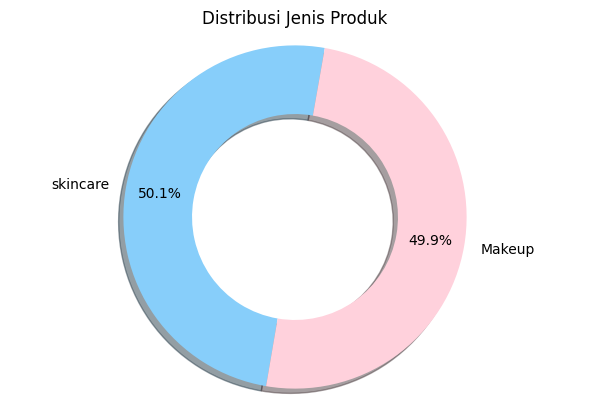

In [14]:
# Create axes
f, ax = plt.subplots(figsize=(6,4)) #membuat plot dimana, figsize untuk menentukan seberapa besar plotnya

# plot donut
donut(sizes, ax, 80, labels, colors=colors, explode=explode, shadow=True) #menginisiasi plot 
ax.set_title('Distribusi Jenis Produk')

plt.show()

In [15]:
df.shape #melihat dimensi data

(15389, 2)

In [16]:
df.isnull().sum() #mengecek data yang kosong

Ulasan    0
jenis     0
dtype: int64

In [17]:
df.shape #melihat dimensi data berdasarkan baris dan kolom

(15389, 2)

In [18]:
df.tail(5) # menampilkan 5 data terbawah

,Ulasan,jenis
15384,"seperti biasa, pengiriman ke Jakarta sangat ce...",Makeup
15385,"beli cushion, dapat angpao dapet eyeliner juga...",Skincare
15386,barang rusak.......,Makeup
15387,"Produk sesuai deskripsi, ED 2023👍👍.............",Skincare
15388,tipe kulitku berminyak tipe kulitku normal tip...,Makeup


# **Preprocesing**

## Cleaning

 Menghapus Noise kata berulang seperti pembeliiii!!! sehingga menjadi pembeli!

In [19]:
#CLEANING
character = ['.',',',';',':','-,','...','?','!','(',')','[',']','{','}','<','>','"','/','\'','#','-','@',
             'a','b','c','d','e','f','g','h','i','j','k','l','m','n','o','p','q','r','s','t','u','v','w','x','y','z',
             'A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']

# hapus karakter yang berulang
def repeatcharClean(text):
  for i in range(len(character)):  # Looping semua karakter di list 'character'
    charac_long = 5                # Awali jumlah maksimum pengulangan karakter (misal 5)
    while charac_long > 2:         # Selama jumlah pengulangan lebih dari 2
      char = character[i]*charac_long        # Buat string karakter berulang (misal 'aaaaa')
      text = text.replace(char,character[i]) # Ganti 'aaaaa' jadi 'a' di teks
      charac_long -= 1             # Kurangi jumlah pengulangan, dari 5 → 4 → 3
  return text

Cleaning data seperti menghapus link dan sebagainya

In [20]:
def clean_review(text):
  # ubah text menjadi huruf kecil
  # ubah enter menjadi spasi
  text = re.sub(r'\n', ' ', text)
  # hapus emoji
  text = emoji.demojize(text)
  text = re.sub(':[A-Za-z_-]+:', ' ', text) # delete emoji
  # hapus emoticon
  text = re.sub(r"([xX;:]'?[dDpPvVoO3)(])", ' ', text)
  # hapus link
  text = re.sub(r"(https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|www\.[a-zA-Z0-9][a-zA-Z0-9-]+[a-zA-Z0-9]\.[^\s]{2,}|https?:\/\/(?:www\.|(?!www))[a-zA-Z0-9]+\.[^\s]{2,}|www\.[a-zA-Z0-9]+\.[^\s]{2,})", "", text)
  # hapus usename
  text = re.sub(r"@[^\s]+[\s]?", ' ', text)
  # hapus hashtag
  text = re.sub(r'#(\S+)', r'\1', text)
  # hapus angka dan beberapa simbol
  text = re.sub('[^a-zA-Z,.?!]+',' ',text)
  # hapus karakter berulang
  text = repeatcharClean(text)
    # hapus titik (termasuk '...')
  text = re.sub(r'\.+', ' ', text)
  # clear spasi
  text = re.sub('[ ]+',' ',text)
  return text

In [21]:
def preprocess_v1(df):
  df_pp = df.copy()
  df_pp.Ulasan = df_pp.Ulasan.map(clean_review)
                                                                                                                                                                                                                                                                                                                                                                    
  # delete empty row
  df_pp.Ulasan.replace('', np.nan, inplace=True)
  df_pp.Ulasan.replace(' ', np.nan, inplace=True)
  df_pp.dropna(subset=['Ulasan'], inplace=True)

  print("Jumlah baris setelah preprocessing:", df_pp.shape)
  return df_pp

fungsi dibawah untuk melakukan clean, berdsasarkan fungsi diatas yang sudah dibuat

In [22]:
df_v1 = preprocess_v1(df)

Jumlah baris setelah preprocessing: (15292, 2)


/tmp/ipykernel_370/2977172745.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pp.Ulasan.replace('', np.nan, inplace=True)
/tmp/ipykernel_370/2977172745.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [23]:
df_v1.shape

(15292, 2)

In [24]:
df_v1 = df_v1.dropna()
df_v1.shape

(15292, 2)

In [25]:
df_v1.head(5)

,Ulasan,jenis
0,Ih bagus banget sih ini cm agak pricey aja Sem...,Skincare
1,tipe kulitku sensitif under tone kulitku netral,Makeup
2,kaget bgt sama packing material nya kirain pes...,Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup
4,tipe kulitku kering under tone kulitku netral,Skincare


In [26]:
df_v1.tail(5)

,Ulasan,jenis
15384,"seperti biasa, pengiriman ke Jakarta sangat ce...",Makeup
15385,"beli cushion, dapat angpao dapet eyeliner juga...",Skincare
15386,barang rusak,Makeup
15387,"Produk sesuai deskripsi, ED",Skincare
15388,tipe kulitku berminyak tipe kulitku normal tip...,Makeup


## Case Folding

In [27]:
# Melakukan casefolding pada kolom 'review_text'
df_v1['Ulasan'] = df_v1['Ulasan'].apply(lambda x: x.casefold()) #mengubah setiap kata dari text menjadi huruf kecil 

# Menampilkan 5 data pertama setelah casefolding
print(df_v1['Ulasan'].head())

0    ih bagus banget sih ini cm agak pricey aja sem...
1     tipe kulitku sensitif under tone kulitku netral 
2    kaget bgt sama packing material nya kirain pes...
3    warna bedaknya cocok banget dan dapat bonus pu...
4        tipe kulitku kering under tone kulitku netral
Name: Ulasan, dtype: object


In [28]:
df_v1.tail(5) #menampilkan 5 data terbawah

,Ulasan,jenis
15384,"seperti biasa, pengiriman ke jakarta sangat ce...",Makeup
15385,"beli cushion, dapat angpao dapet eyeliner juga...",Skincare
15386,barang rusak,Makeup
15387,"produk sesuai deskripsi, ed",Skincare
15388,tipe kulitku berminyak tipe kulitku normal tip...,Makeup


## Normalisasi

In [29]:
# Membaca file kamus kata alay dari path yang telah ditentukan ke dalam dataframe pandas
kamus_alay = pd.read_csv(kamus_alay_path)

# Membuat dictionary kosong untuk menyimpan mapping dari kata alay ke kata normal
normalize_word_dict = {}

# Melakukan iterasi untuk setiap baris dalam dataframe kamus_alay
for index, row in kamus_alay.iterrows():
    # Jika kata alay (pada kolom pertama) belum ada dalam dictionary normalize_word_dict
    if row[0] not in normalize_word_dict:
        # Tambahkan pasangan kata alay (sebagai key) dan kata normalnya (sebagai value) ke dalam dictionary
        normalize_word_dict[row[0]] = row[1]


/tmp/ipykernel_370/2586887995.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if row[0] not in normalize_word_dict:
/tmp/ipykernel_370/2586887995.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalize_word_dict[row[0]] = row[1]


In [30]:
# Fungsi untuk melakukan normalisasi kata dalam sebuah teks (mengganti kata alay ke kata normal)
def normalize_review(text):
    # Cek apakah nilai text kosong atau NaN
    if pd.isna(text) or text.strip() == "":
        # Jika kosong/NaN, kembalikan dua nilai: list kosong dan string kosong
        return [], ""  # Pastikan selalu mengembalikan dua nilai agar konsisten dengan fungsi lain yang mungkin dipakai

    # Tokenisasi teks menjadi list kata-kata
    list_text = word_tokenize(text)

    # Lakukan normalisasi: jika kata ada di kamus alay, ganti dengan kata normalnya
    list_text = [normalize_word_dict[term] if term in normalize_word_dict else term for term in list_text]

    # Gabungkan kembali list kata menjadi string kalimat normal
    text = " ".join(list_text)

    # Kembalikan hasil normalisasi dalam bentuk string kalimat
    return text


In [31]:
# Fungsi untuk melakukan preprocessing tahap 2: normalisasi kata dan pembersihan baris kosong
def preprocess_v2(df):
    # Duplikasi dataframe agar data aslinya tidak berubah
    df_pp = df.copy()

    # Terapkan fungsi normalisasi ke kolom 'Ulasan' untuk setiap barisnya
    df_pp.Ulasan = df_pp.Ulasan.map(normalize_review)

    # Mengganti string kosong ('') di kolom 'Ulasan' menjadi NaN
    df_pp.Ulasan.replace('', np.nan, inplace=True)

    # Mengganti string spasi tunggal (' ') di kolom 'Ulasan' menjadi NaN
    df_pp.Ulasan.replace(' ', np.nan, inplace=True)

    # Menghapus baris yang nilai di kolom 'Ulasan' adalah NaN
    df_pp.dropna(subset=['Ulasan'], inplace=True)

    # Mengembalikan dataframe hasil preprocessing
    return df_pp

In [32]:
# take a while
df_v2  = preprocess_v2(df_v1) #melakukan cleaning berdasarkan fungsi yg sudah di buat

/tmp/ipykernel_370/3864800763.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pp.Ulasan.replace('', np.nan, inplace=True)
/tmp/ipykernel_370/3864800763.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [33]:
df_v2.shape #melihat dimensi data

(15292, 2)

In [34]:
df_v2.head(5) #melihat 5 data teratas

,Ulasan,jenis
0,ih bagus banget sih ini cuma agak pricey saja ...,Skincare
1,tipe kulitku sensitif under tone kulitku netral,Makeup
2,kaget banget sama packing material nya mengira...,Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup
4,tipe kulitku kering under tone kulitku netral,Skincare


In [35]:
df_v2.tail(5) #melihat 5 data terbawah

,Ulasan,jenis
15384,"seperti biasa , pengiriman ke jakarta sangat c...",Makeup
15385,"beli cushion , dapat angpao dapat eyeliner jug...",Skincare
15386,barang rusak,Makeup
15387,"produk sesuai deskripsi , ed",Skincare
15388,tipe kulitku berminyak tipe kulitku normal tip...,Makeup


In [36]:
df_v2.isnull().sum() #mengecek data kosong

Ulasan    0
jenis     0
dtype: int64

# Save data ke csv lalu translate di spreadsheet

Data yang sudah di cleaning di save lalu di translate ke bahasa inggris menggunakan bantuan google spreadsheet

In [37]:
df_v2.to_csv('DataBersih.csv', index=False) #save data yang sudah bersih

In [38]:
df_v2.head() #melihat 5 data teratas

,Ulasan,jenis
0,ih bagus banget sih ini cuma agak pricey saja ...,Skincare
1,tipe kulitku sensitif under tone kulitku netral,Makeup
2,kaget banget sama packing material nya mengira...,Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup
4,tipe kulitku kering under tone kulitku netral,Skincare


setelah itu data ini akan di translated di spreadsheet

# Panggil Data yang sudah di translated

panggil data yang sudah di translated menggunakan bantuan google spreadsheet

In [39]:
df = pd.read_csv('/kaggle/input/data-bersih-setelah-trans/databersih_setelah translated.csv') #import data
df.head() #menampilkan 5 data teratas

,Ulasan,jenis,Translate id to eng,Translated eng to id
0,ih bagus banget sih ini cuma agak pricey saja ...,Skincare,"Oh, this is really good, it's just a bit price...","Wah, ini benar-benar bagus, hanya saja hargany..."
1,tipe kulitku sensitif under tone kulitku netral,Makeup,My skin type is sensitive and my skin underton...,Jenis kulitku sensitif dan warna kulitku netral.
2,kaget banget sama packing material nya mengira...,Makeup,I was really surprised by the packaging materi...,Saya benar-benar terkejut dengan bahan pengema...
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup,The color of the powder is really suitable and...,Warna bedaknya sesuai banget dan dapat bonus d...
4,tipe kulitku kering under tone kulitku netral,Skincare,My skin type is dry and my skin tone is neutral.,Jenis kulit saya kering dan warna kulit saya n...


# Label Data Menggunakan vader

data yang sudah di cleaning dan di translated selanjutnya di lakukan pelabelan menggunakan vader dimana kolom yang digunakan untuk mennentukan nilai compounds adalah kolom yg sudah di translate ke bahasa inggris

In [40]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # Import library VADER untuk analisis sentimen
import pandas as pd                                                   # Import pandas untuk olah data tabular

# Inisialisasi VADER analyzer
analyzer = SentimentIntensityAnalyzer() #untuk menghitung nilai compounds dari setiap kata

# Definisikan threshold label sentimen berdasarkan skor compound
threshold_pos = 0.05     # Skor minimal untuk dianggap positif
threshold_neg = -0.05    # Skor maksimal untuk dianggap negatif

# Fungsi pelabelan sentimen
def label_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']   # Hitung skor dan mengambil nilia compound VADER untuk teks
    if score >= threshold_pos:                           # Jika skor di atas threshold positif
        return 'positif'                                  # Kembalikan label 'positif'
    elif score <= threshold_neg:                         # Jika skor di bawah threshold negatif
        return 'negatif'                                  # Kembalikan label 'negatif'
    else:                                                 # Jika di antaranya
        return 'netral'                                   # Kembalikan label 'netral'

# Terapkan fungsi pelabelan ke kolom hasil translate ke bahasa Inggris
df['vader_label'] = df['Translate id to eng'].apply(label_sentiment)  # Buat kolom baru 'vader_label' berisi hasil klasifikasi

# Tampilkan 5 baris pertama hasilnya
print(df[['Ulasan', 'Translate id to eng', 'vader_label', 'Translated eng to id']].head())

# Simpan dataframe hasil labeling ke file CSV baru
df.to_csv('hasil_vader_label.csv', index=False)           # Simpan hasil ke file CSV tanpa index

                                              Ulasan  \
0  ih bagus banget sih ini cuma agak pricey saja ...   
1    tipe kulitku sensitif under tone kulitku netral   
2  kaget banget sama packing material nya mengira...   
3  warna bedaknya cocok banget dan dapat bonus pu...   
4      tipe kulitku kering under tone kulitku netral   

                                 Translate id to eng vader_label  \
0  Oh, this is really good, it's just a bit price...     positif   
1  My skin type is sensitive and my skin underton...      netral   
2  I was really surprised by the packaging materi...     positif   
3  The color of the powder is really suitable and...     positif   
4   My skin type is dry and my skin tone is neutral.      netral   

                                Translated eng to id  
0  Wah, ini benar-benar bagus, hanya saja hargany...  
1   Jenis kulitku sensitif dan warna kulitku netral.  
2  Saya benar-benar terkejut dengan bahan pengema...  
3  Warna bedaknya sesuai banget da

In [41]:
df.head() #menampilkan 5 data teratas

,Ulasan,jenis,Translate id to eng,Translated eng to id,vader_label
0,ih bagus banget sih ini cuma agak pricey saja ...,Skincare,"Oh, this is really good, it's just a bit price...","Wah, ini benar-benar bagus, hanya saja hargany...",positif
1,tipe kulitku sensitif under tone kulitku netral,Makeup,My skin type is sensitive and my skin underton...,Jenis kulitku sensitif dan warna kulitku netral.,netral
2,kaget banget sama packing material nya mengira...,Makeup,I was really surprised by the packaging materi...,Saya benar-benar terkejut dengan bahan pengema...,positif
3,warna bedaknya cocok banget dan dapat bonus pu...,Makeup,The color of the powder is really suitable and...,Warna bedaknya sesuai banget dan dapat bonus d...,positif
4,tipe kulitku kering under tone kulitku netral,Skincare,My skin type is dry and my skin tone is neutral.,Jenis kulit saya kering dan warna kulit saya n...,netral


In [42]:
df.tail(5) #menampilkan 5 data terbawah

,Ulasan,jenis,Translate id to eng,Translated eng to id,vader_label
15287,"seperti biasa , pengiriman ke jakarta sangat c...",Makeup,"As usual, shipping to Jakarta is very fast, th...","Seperti biasa, pengiriman ke Jakarta sangat ce...",positif
15288,"beli cushion , dapat angpao dapat eyeliner jug...",Skincare,"buy a cushion, get angpao, get an eyeliner too...","beli cushion, dapet angpao, dapet eyeliner jug...",negatif
15289,barang rusak,Makeup,damaged goods,barang rusak,negatif
15290,"produk sesuai deskripsi , ed",Skincare,"product as described, ed","produk sesuai deskripsi, ed",netral
15291,tipe kulitku berminyak tipe kulitku normal tip...,Makeup,my skin type is oily my skin type is normal my...,tipe kulitku berminyak tipe kulitku normal tip...,positif


In [43]:
# Ambil kolom yang dibutuhkan
df = df[['Ulasan', 'vader_label', 'jenis']] #mengambil kolom yang akan digunakan saja

# Cek hasilnya
print(df.head()) #menampilkan 5 data teratas

# Kalau mau disimpan ke CSV
df.to_csv('filtered_vader_result.csv', index=False) #save data ke csv

                                              Ulasan vader_label     jenis
0  ih bagus banget sih ini cuma agak pricey saja ...     positif  Skincare
1    tipe kulitku sensitif under tone kulitku netral      netral    Makeup
2  kaget banget sama packing material nya mengira...     positif    Makeup
3  warna bedaknya cocok banget dan dapat bonus pu...     positif    Makeup
4      tipe kulitku kering under tone kulitku netral      netral  Skincare


In [44]:
df.shape #melihat dimensi data

(15292, 3)

# Lihat Proporsi Data berdasarkan Label Vader

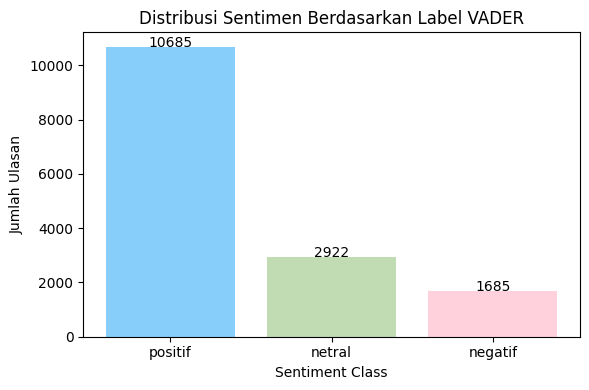

In [45]:
import matplotlib.pyplot as plt  # Import library matplotlib untuk visualisasi data

# Ambil jumlah masing-masing label sentimen dari kolom 'vader_label'
sizes = df.vader_label.value_counts()   

# Tentukan urutan label yang mau ditampilkan di chart
labels = ['positif', 'netral', 'negatif']

# Tentukan warna untuk tiap kategori label
colors = ['lightskyblue', '#C1DBB3', '#FFD1DC']

# Buat figure baru dengan ukuran 6x4 inch
plt.figure(figsize=(6, 4))

# Buat bar chart: sumbu X = labels, sumbu Y = jumlah label (sesuai urutan di 'labels')
plt.bar(labels, sizes[labels], color=colors)

# Tambahkan label ke sumbu X
plt.xlabel('Sentiment Class')

# Tambahkan label ke sumbu Y
plt.ylabel('Jumlah Ulasan')

# Tambahkan judul chart
plt.title('Distribusi Sentimen Berdasarkan Label VADER')

# Tampilkan nilai jumlah di atas masing-masing bar
for i, v in enumerate(sizes[labels]):        # Loop tiap bar
    plt.text(i, v + 5, str(v), ha='center')  # Tulis nilai di atas bar dengan jarak +5

# Perbaiki tata letak supaya rapi
plt.tight_layout()

# Tampilkan chart ke layar
plt.show()

# Buat Kolom Baru untuk di stratify berdasarkan kolom Vader label dan jenis

Membuat kolom baru dimana kolom baru adalah kolom yang di hasilkan dari hasil kombinasi kolom vader label yang
berisi sentiment positif,negatif,neutral, dan kolom jenis yang berisi makeup dan skincare, kolom baru ini
yang akan menjadi kolom stratify, sehingga stratify nntinya akan di bagi berdasarkan 6 category

In [46]:
df['stratify_label'] = df['vader_label'].astype(str) + "_" + df['jenis'].astype(str) #astypr str digunakan untuk memastikan kedua kolom diubah menjadi string
df.head() #menampilkan 5 data tertas

,Ulasan,vader_label,jenis,stratify_label
0,ih bagus banget sih ini cuma agak pricey saja ...,positif,Skincare,positif_Skincare
1,tipe kulitku sensitif under tone kulitku netral,netral,Makeup,netral_Makeup
2,kaget banget sama packing material nya mengira...,positif,Makeup,positif_Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,positif,Makeup,positif_Makeup
4,tipe kulitku kering under tone kulitku netral,netral,Skincare,netral_Skincare


In [47]:
#menganti nama kolom sesuai dengan nama kolom yang digunakan pada variable yang di pakai di fungsi2 dindobert
df.rename(columns={'Ulasan': 'review_text', 'vader_label': 'category'}, inplace=True) 

In [48]:
df['category'].value_counts() #melihat banyak persebaran data berdasarkan categorynya/sentiment label

category
positif    10685
netral      2922
negatif     1685
Name: count, dtype: int64

In [49]:
df.head() #menampilkan 5 data teratas

,review_text,category,jenis,stratify_label
0,ih bagus banget sih ini cuma agak pricey saja ...,positif,Skincare,positif_Skincare
1,tipe kulitku sensitif under tone kulitku netral,netral,Makeup,netral_Makeup
2,kaget banget sama packing material nya mengira...,positif,Makeup,positif_Makeup
3,warna bedaknya cocok banget dan dapat bonus pu...,positif,Makeup,positif_Makeup
4,tipe kulitku kering under tone kulitku netral,netral,Skincare,netral_Skincare


In [50]:
# Tambahkan kolom panjang teks
df['panjang_teks'] = df['review_text'].apply(len)

# Cari baris dengan teks terpanjang
teks_terpanjang = df.loc[df['panjang_teks'].idxmax()]

# Tampilkan hasil
print("Teks terpanjang:")
print(teks_terpanjang['review_text'])
print("\nPanjangnya:", teks_terpanjang['panjang_teks'])

Teks terpanjang:
setiap beli yang model alimentary paste kemasannya milliliter directorate for inter services intelligence tinggal separo , tapi kalau yang milliliter directorate for inter services intelligence penuh ini yang kesekian kalinya semoga kedepan lebih baik mutu barang dan pengiriman

Panjangnya: 278


# **Spliting Data**

In [51]:
# Stratified split: train dan temp (test + val)
train_set, temp_df = train_test_split(
    df,                                           # Dataframe yang akan dibagi
    test_size=0.3,                                # 30% data masuk ke temp_df (test + val), 70% ke train_set
    stratify=df['stratify_label'],                # Stratifikasi berdasarkan kolom 'stratify_label' agar proporsi kelas seimbang
    random_state=42                               # Random seed supaya hasil pembagian konsisten tiap kali dijalankan
)

# Stratified split: val dan test dari temp
val_set, test_set = train_test_split(
    temp_df,                                      # Data sementara (30% data dari awal) yang akan dibagi dua
    test_size=0.5,                                # 50% dari temp_df ke test_set, 50% ke val_set (berarti masing-masing 15% dari total awal)
    stratify=temp_df['stratify_label'],           # Stratifikasi lagi berdasarkan 'stratify_label' agar proporsi tetap seimbang di val dan test
    random_state=42                               # Random seed yang sama agar hasil pembagian tetap konsisten
)

In [52]:
#melihat dimensi dari setiap hasil split data
print(f'Train shape: {train_set.shape}') 
print(f'Val shape: {val_set.shape}')
print(f'Test shape: {test_set.shape}')

Train shape: (10704, 5)
Val shape: (2294, 5)
Test shape: (2294, 5)


In [53]:
train_set['category'].value_counts() #melihat persebaran berdasarkan kolom category di data train

category
positif    7480
netral     2045
negatif    1179
Name: count, dtype: int64

In [54]:
train_set['jenis'].value_counts() #melihat persebaran berdasarkan kolom jenis di data train

jenis
Skincare    5359
Makeup      5345
Name: count, dtype: int64

In [55]:
val_set['category'].value_counts() #melihat persebaran berdsarkan kolom category di data validasi

category
positif    1602
netral      438
negatif     254
Name: count, dtype: int64

In [56]:
test_set['category'].value_counts() #melihat persebaran berdsarkan kolom category di data test

category
positif    1603
netral      439
negatif     252
Name: count, dtype: int64

In [57]:
train_set.head() #melihat 5 data tratas di data train

,review_text,category,jenis,stratify_label,panjang_teks
7007,tipe kulitku berminyak tipe kulitku sensitif u...,positif,Skincare,positif_Skincare,166
9725,estimasi tiba mengecewakan,negatif,Skincare,negatif_Skincare,26
6910,produknya,netral,Makeup,netral_Makeup,9
2971,paketnya sudah sampai terima kasih,positif,Skincare,positif_Skincare,34
13903,"membuat muka anaak ku lebih cerah , menipiskan...",positif,Makeup,positif_Makeup,155


In [58]:
train_set.to_csv('train_set112.csv') #save data ke csv
val_set.to_csv('val_set112.csv') # save data ke csv
test_set.to_csv('test_set112.csv') # save data ke csv

# Ambil Kolom Ulasan Dan Category saja

In [59]:
# Ambil kolom 'Ulasan' dan 'vader_label' saja untuk masing-masing set
train_data = train_set[['review_text', 'category']]
val_data = val_set[['review_text', 'category']]
test_data = test_set[['review_text', 'category']]

# Cek shape masing-masing hasil
print(f'Train shape: {train_data.shape}')
print(f'Val shape: {val_data.shape}')
print(f'Test shape: {test_data.shape}')

Train shape: (10704, 2)
Val shape: (2294, 2)
Test shape: (2294, 2)


In [60]:
train_data.head() #melihat data tratas dari data train

,review_text,category
7007,tipe kulitku berminyak tipe kulitku sensitif u...,positif
9725,estimasi tiba mengecewakan,negatif
6910,produknya,netral
2971,paketnya sudah sampai terima kasih,positif
13903,"membuat muka anaak ku lebih cerah , menipiskan...",positif


In [61]:
# Simpan data lengkap (dengan kolom jenis) untuk nanti merge prediksi
train_set_full = train_set.copy()
val_set_full = val_set.copy()
test_set_full = test_set.copy()

# Hanya simpan ke file tsv yang input dan label saja (untuk model training)
train_data = train_set[['review_text', 'category']]
val_data = val_set[['review_text', 'category']]
test_data = test_set[['review_text', 'category']]

train_data.to_csv('train_set1.tsv', sep='\t', header=None, index=False)
val_data.to_csv('val_set1.tsv', sep='\t', header=None, index=False)
test_data.to_csv('test_set1.tsv', sep='\t', header=None, index=False)


In [62]:
train_data.to_csv('train_set1.csv')
val_data.to_csv('val_set1.csv')
test_data.to_csv('test_set1.csv')

# **Modeling**

## commons function indobert

In [63]:
###
# common functions
###

# Fungsi untuk set random seed agar hasil eksperimen bisa direproduksi (hasil acak tetap sama setiap run)
def set_seed(seed=42):
    random.seed(seed)                      # Set seed untuk modul random bawaan Python
    np.random.seed(seed)                   # Set seed untuk modul numpy
    torch.manual_seed(seed)                # Set seed untuk CPU di PyTorch
    torch.cuda.manual_seed(seed)           # Set seed untuk GPU di PyTorch (kalau pakai CUDA)

# Fungsi untuk menghitung jumlah parameter di model
def count_param(module, trainable=False):
    if trainable:
        # Hitung hanya parameter yang ikut di-train (requires_grad=True)
        return sum(p.numel() for p in module.parameters() if p.requires_grad)
    else:
        # Hitung semua parameter (baik trainable maupun non-trainable)
        return sum(p.numel() for p in module.parameters())

# Fungsi untuk mendapatkan current learning rate dari optimizer
def get_lr(optimizer):
    for param_group in optimizer.param_groups:   # param_groups bisa lebih dari 1 kalau learning rate-nya beda-beda per layer
        return param_group['lr']                 # Ambil nilai learning rate dari param group pertama (umumnya cuma 1 group)

# Fungsi untuk mengubah dictionary metrik jadi string rapi untuk ditampilkan saat training
def metrics_to_string(metric_dict):
    string_list = []                                          # Inisialisasi list kosong
    for key, value in metric_dict.items():                    # Looping setiap item di dictionary metrik
        string_list.append('{}:{:.2f}'.format(key, value))    # Format jadi string key: value (2 desimal)
    return ' '.join(string_list)                              # Gabungkan semua string jadi satu kalimat dipisah spasi


In [64]:
# Set random seed
set_seed(42)

## Load Model

In [65]:
# Load Tokenizer and Config
tokenizer = BertTokenizer.from_pretrained('indobenchmark/indobert-base-p2')  
# Load tokenizer IndoBERT dari Huggingface model hub (indobenchmark/indobert-base-p2)

config = BertConfig.from_pretrained('indobenchmark/indobert-base-p2')        
# Load konfigurasi default IndoBERT (seperti jumlah hidden layer, hidden size, dll)

config.num_labels = DocumentSentimentDataset.NUM_LABELS                     
# Ubah konfigurasi: set jumlah output label sesuai jumlah label di dataset (biasanya 3 untuk positif, negatif, netral)
# Di sini DocumentSentimentDataset.NUM_LABELS harus sudah didefinisikan di class dataset kamu sebelumnya

# Instantiate model
model = BertForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p2', config=config)
# Load pre-trained IndoBERT model khusus untuk sequence classification
# Dengan config yang sudah dimodifikasi sesuai jumlah label di atas

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [66]:
# Struktur model
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

## Tokenisasi

In [67]:
# Kalimat yang mau di-tokenisasi
text = "ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you"

# Tokenisasi dan padding sampai panjang 512 token
tokens = tokenizer.encode_plus(
    text,
    add_special_tokens=True,      # tambahkan [CLS] dan [SEP]
    max_length=512,               # panjang maksimal
    padding='max_length',         # padding sampai max_length
    truncation=True,              # potong kalau kepanjangan
    return_tensors='pt'           # hasil sebagai tensor PyTorch
)

# Ambil token IDs
input_ids = tokens['input_ids'][0].tolist()

# Cetak hasil
print("Teks setelah tokenisasi:", input_ids)
print("\nBentuk tokenisasi:", len(input_ids))

Teks setelah tokenisasi: [2, 7346, 1305, 2174, 1966, 92, 2279, 2839, 12669, 30371, 377, 1671, 1209, 12686, 17, 423, 4525, 57, 16627, 3299, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

## Embeding

In [68]:
import torch
from transformers import BertTokenizer, BertConfig, BertForSequenceClassification

# Atur agar PyTorch menampilkan tensor tanpa dipotong
#torch.set_printoptions(threshold=torch.inf)

# Tentukan device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Teks contoh
text = "ih"

# Tokenisasi + pindah ke device
inputs = tokenizer(text, return_tensors="pt").to(device)

# Ambil hasil embedding
embeddings = model.bert.embeddings(input_ids=inputs["input_ids"])

# Tampilkan hasil embedding panjang
print("Hasil embedding (ih):")
print(embeddings)
print("Shape embedding:", embeddings.shape)  # (batch_size, seq_len, hidden_size)


Hasil embedding (full):
tensor([[[-1.0168,  0.1515,  0.2470,  ..., -0.7547, -0.7400, -0.5116],
         [ 0.7123,  0.9035, -1.5591,  ..., -0.8211,  0.1310, -0.6389],
         [ 0.2701, -0.6125,  0.0378,  ..., -0.7208, -0.3508,  0.5041],
         ...,
         [-0.4532, -0.6675,  0.2772,  ...,  0.9184,  0.2998, -0.1939],
         [-0.2532,  0.2703, -1.4429,  ...,  1.1515,  0.2533,  0.7606],
         [ 0.7160, -0.0452, -0.1199,  ..., -0.1190, -0.2739,  0.7987]]],
       device='cuda:0', grad_fn=<NativeLayerNormBackward0>)
Shape embedding: torch.Size([1, 21, 768])


## Output encoder

In [69]:
import torch

# Pastikan model dan data di device yang sama
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Teks contoh
text = "ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you"

# Tokenisasi dan pindahkan ke device
inputs = tokenizer(text, return_tensors="pt").to(device)

# ====== Ambil nilai embedding awal ======
embeddings = model.bert.embeddings(input_ids=inputs["input_ids"])

# Ubah attention_mask jadi bool agar kompatibel
attention_mask = inputs["attention_mask"].bool()

# Forward ke encoder bert 
encoder_outputs = model.bert.encoder(
    embeddings,
    attention_mask=attention_mask
)

last_hidden_state = encoder_outputs.last_hidden_state

print("Nilai encoder output:")
print(last_hidden_state)
print("Shape output:", last_hidden_state.shape)

Nilai encoder output:
tensor([[[ 1.2298e+00,  2.2730e+00,  6.5345e-04,  ..., -1.7667e-01,
          -6.5099e-01,  5.8313e-01],
         [ 1.0171e+00,  1.2519e+00, -1.2228e-01,  ..., -9.5960e-01,
          -1.5858e+00,  7.1851e-01],
         [ 1.5166e+00,  1.5169e-01,  1.2508e+00,  ...,  9.3012e-01,
          -1.1572e+00,  1.5654e+00],
         ...,
         [ 1.7475e-01, -8.4587e-01,  8.8437e-01,  ...,  1.4658e-02,
          -8.7868e-01,  2.1376e+00],
         [ 2.8243e-01, -4.5177e-01,  1.3248e+00,  ...,  4.3832e-01,
          -1.4161e+00, -2.5090e-01],
         [ 1.7060e+00,  8.2616e-01,  7.4326e-01,  ...,  6.3147e-02,
          -6.8667e-01,  6.3685e-01]]], device='cuda:0',
       grad_fn=<NativeLayerNormBackward0>)
Shape output: torch.Size([1, 21, 768])


## Output self attention

In [70]:
# Variabel untuk menampung Q, K, V
saved_qkv = {}

def hook_qkv(module, input, output):
    # module = BertSelfAttention
    saved_qkv['query'] = module.query.weight.detach().cpu()
    saved_qkv['key'] = module.key.weight.detach().cpu()
    saved_qkv['value'] = module.value.weight.detach().cpu()

# Pasang hook pada layer attention pertama (bisa diubah ke layer lain)
attention_layer = model.bert.encoder.layer[0].attention.self
hook_handle = attention_layer.register_forward_hook(hook_qkv)

# Jalankan forward sekali
_ = model(**inputs)

# Tampilkan
print("Nilai query:\n", saved_qkv['query'])
print("Nilai key:\n", saved_qkv['key'])
print("Nilai value:\n", saved_qkv['value'])

# Lepas hook jika sudah selesai
hook_handle.remove()

Nilai query:
 tensor([[-0.0274, -0.0209, -0.0130,  ..., -0.0646, -0.0232,  0.0482],
        [-0.0102,  0.0017, -0.0095,  ...,  0.0069,  0.0235,  0.0054],
        [-0.0006,  0.0077,  0.0044,  ...,  0.0142, -0.0101,  0.0034],
        ...,
        [-0.0289,  0.0270,  0.0218,  ..., -0.0325,  0.0063,  0.0017],
        [ 0.0342, -0.0027, -0.0110,  ..., -0.0290, -0.0247,  0.0304],
        [ 0.0118, -0.0047, -0.0436,  ...,  0.0332,  0.0057,  0.0063]])
Nilai key:
 tensor([[ 0.0109, -0.0243,  0.0018,  ..., -0.0161,  0.0249, -0.0382],
        [-0.0308, -0.0102, -0.0032,  ...,  0.0252,  0.0145, -0.0251],
        [ 0.0101,  0.0060, -0.0079,  ..., -0.0041, -0.0031, -0.0024],
        ...,
        [ 0.0266,  0.0221,  0.0133,  ...,  0.0202,  0.0063, -0.0141],
        [ 0.0054,  0.0184, -0.0038,  ...,  0.0003,  0.0021, -0.0212],
        [ 0.0371, -0.0121,  0.0180,  ..., -0.0049, -0.0187, -0.0331]])
Nilai value:
 tensor([[ 0.0207, -0.0324, -0.0071,  ..., -0.0115,  0.0107, -0.0034],
        [-0.0407, -0.0

## Prepare Dataset untuk model

In [71]:
# urutan label 
DocumentSentimentDataset.LABEL2INDEX = {
    "negatif": 0,    # Label 'negatif' di-mapping ke index 0
    "netral": 1,     # Label 'netral' di-mapping ke index 1
    "positif": 2     # Label 'positif' di-mapping ke index 2
}

# Mapping sebaliknya: dari index ke label
DocumentSentimentDataset.INDEX2LABEL = {
    0: "negatif",    # Index 0 di-mapping ke label 'negatif'
    1: "netral",     # Index 1 di-mapping ke label 'netral'
    2: "positif"     # Index 2 di-mapping ke label 'positif'
}

# Assign ke alias w2i dan i2w (supaya lebih singkat dipanggil di kode)
w2i, i2w = DocumentSentimentDataset.LABEL2INDEX, DocumentSentimentDataset.INDEX2LABEL

# Cek hasil mapping label ke index
print(w2i)

# Cek hasil mapping index ke label
print(i2w)

{'negatif': 0, 'netral': 1, 'positif': 2}
{0: 'negatif', 1: 'netral', 2: 'positif'}


In [72]:
#memanggil dataset yang akan di pakai
train_dataset_path = '/kaggle/working/train_set1.tsv'
valid_dataset_path = '/kaggle/working/val_set1.tsv'
test_dataset_path = '/kaggle/working/test_set1.tsv'

In [73]:
# fungsi dataset loader dari utils IndoNLU

# Load dataset training, preprocessing dengan tokenizer, dan opsional lowercase
train_dataset = DocumentSentimentDataset(train_dataset_path, tokenizer, lowercase=True)

# Load dataset validasi dengan setting yang sama
valid_dataset = DocumentSentimentDataset(valid_dataset_path, tokenizer, lowercase=True)

# Load dataset testing dengan setting yang sama
test_dataset = DocumentSentimentDataset(test_dataset_path, tokenizer, lowercase=True)


# Buat DataLoader untuk training
train_loader = DocumentSentimentDataLoader(
    dataset=train_dataset,        # Dataset hasil tokenisasi
    max_seq_len=512,              # Maksimal panjang token sequence per data (truncating kalau lebih panjang)
    batch_size=8,                 # Jumlah data per batch
    num_workers=4,                # Jumlah worker thread untuk load data (buat lebih cepat)
    shuffle=True                  # Acak data setiap epoch (supaya training lebih stabil)
)

# DataLoader untuk validasi
valid_loader = DocumentSentimentDataLoader(
    dataset=valid_dataset,        # Dataset validasi
    max_seq_len=512,              
    batch_size=8,                 
    num_workers=4,  
    shuffle=False 
)

# DataLoader untuk testing
test_loader = DocumentSentimentDataLoader(
    dataset=test_dataset,         # Dataset testing
    max_seq_len=512,              
    batch_size=8,                 
    num_workers=4,                
    shuffle=False              # Tidak perlu diacak saat testing
)

## Uji Coba Pretrained Model

In [74]:
# Import library yang dibutuhkan
import torch
import torch.nn.functional as F

# Kalimat input yang akan diprediksi sentimennya
text = 'jelek sekali'

# Tokenisasi kalimat menjadi subword token ID sesuai tokenizer IndoBERT
subwords = tokenizer.encode(text)

# Ambil device yang dipakai oleh parameter model (bisa 'cuda' atau 'cpu')
device = next(model.parameters()).device

# Ubah list subwords jadi tensor long, reshape ke bentuk (1, jumlah_token)
# lalu pindahkan ke device (CPU atau GPU)
subwords_tensor = torch.LongTensor(subwords).unsqueeze(0).to(device)
# .unsqueeze(0) = sama dengan .view(1, -1), lebih clean

# Lakukan forward pass ke model untuk mendapatkan logits (output mentah sebelum softmax)
with torch.no_grad():  # nonaktifkan gradient tracking (hemat memory & lebih cepat)
    logits = model(subwords_tensor)[0]

# Hitung probabilitas masing-masing kelas dengan softmax
probs = F.softmax(logits, dim=-1).squeeze()

# Ambil index label dengan nilai probabilitas tertinggi
label_idx = torch.argmax(probs).item()

# Tampilkan hasil prediksi label + confidence (probabilitas) dalam persen
print(f"Text: '{text}' | Label: {i2w[label_idx]} ({probs[label_idx] * 100:.3f}%)")

Text: 'jelek sekali' | Label: netral (38.400%)


In [75]:
# Teks ulasan yang akan diprediksi sentimennya
text = "ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you"

# Tokenisasi teks menjadi subword token IDs sesuai tokenizer model
subwords = tokenizer.encode(text)

# Ubah list token IDs menjadi tensor LongTensor, reshape jadi bentuk (1, sequence_length) lalu pindahkan ke device model (CPU/GPU)
subwords = torch.LongTensor(subwords).view(1, -1).to(model.device)

# Lakukan forward pass ke model untuk menghasilkan logits (output sebelum softmax)
logits = model(subwords)[0]

# Ambil index label dengan nilai logit tertinggi (k=1), hasilnya adalah index label prediksi
label = torch.topk(logits, k=1, dim=-1)[1].squeeze().item()

# Cetak teks ulasan, label hasil prediksi (berdasarkan i2w, mapping index ke nama label), dan confidence (probabilitas prediksi)
print(f'Text: {text} | Label : {i2w[label]} ({F.softmax(logits, dim=-1).squeeze()[label] * 100:.3f}%)')

# Cetak nilai logits mentah dari model (sebelum softmax) dalam bentuk numpy array
print(f"Logits: {logits.detach().cpu().numpy()}")

Text: ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you | Label : netral (41.156%)
Logits: [[-0.35587    -0.11182985 -0.54826814]]


# **Fine Tuning & Prediksi Evaluasi**

In [76]:
# Tentukan optimizer
optimizer = optim.Adam(model.parameters(), lr=3e-5) #untuk menginisiasi optimizer dan learning rate yang digunakan
model = model.to("cuda")  #untuk meninisiasi bahwa yg dipakai adalah gpu, bukan cpu, jika cpu maka cuda diganti menjadi cpu

## Training

In [77]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# 1️⃣ Kumpulkan semua label dari train_loader
train_labels = []  # Inisialisasi list kosong untuk label

for data in train_loader:
    label_batch = data[2]  # Ambil label di indeks ke-2 (format: (input_ids, attention_mask, label))
    label_array = np.array(label_batch).reshape(-1)  # Ubah ke array 1 dimensi
    train_labels.extend(label_array.tolist())  # Tambahkan ke list train_labels

# 2️⃣ Hitung class weights berdasarkan distribusi label di data training
class_weights = compute_class_weight(
    class_weight='balanced',            # Mode balanced → bobot disesuaikan otomatis
    classes=np.array([0, 1, 2]),         # Daftar label kelas (0 = negatif, 1 = netral, 2 = positif)
    y=train_labels                       # Label dari data training
)

# 3️⃣ Konversi class_weights ke tensor dan pindahkan ke GPU
class_weights = torch.tensor(class_weights, dtype=torch.float).to('cuda')

# 4️⃣ Tampilkan hasil bobot tiap kelas
print("Class Weights:", class_weights)

Class Weights: tensor([3.0263, 1.7447, 0.4770], device='cuda:0')


In [78]:
import torch

# Fungsi forward untuk sequence classification IndoBERT
def forward_sequence_classification(model, batch_data, i2w, is_test=False, device='cpu', **kwargs):
    # Unpack batch data sesuai jumlah item dalam batch (3 atau 4)
    if len(batch_data) == 3:
        (subword_batch, mask_batch, label_batch) = batch_data
        token_type_batch = None  # Kalau tidak ada token type
    elif len(batch_data) == 4:
        (subword_batch, mask_batch, token_type_batch, label_batch) = batch_data

    # Konversi semua batch ke tensor sesuai tipe data
    subword_batch = torch.LongTensor(subword_batch)                # Subword token IDs
    mask_batch = torch.FloatTensor(mask_batch)                     # Attention mask
    token_type_batch = torch.LongTensor(token_type_batch) if token_type_batch is not None else None
    label_batch = torch.LongTensor(label_batch)                    # Label ground truth

    # Pindahkan tensor ke device (CPU atau GPU)
    if device == "cuda":
        subword_batch = subword_batch.cuda()
        mask_batch = mask_batch.cuda()
        token_type_batch = token_type_batch.cuda() if token_type_batch is not None else None
        label_batch = label_batch.cuda()

    # Forward pass ke model, ambil hasil logits
    outputs = model(subword_batch, attention_mask=mask_batch, token_type_ids=token_type_batch)
    logits = outputs.logits  # ambil output logits sebelum softmax

    # Definisikan loss function: cek apakah class_weights disediakan di kwargs
    if 'class_weights' in kwargs:
        class_weights = kwargs['class_weights']
        # Pakai class-weighted CrossEntropyLoss kalau ada
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
    else:
        # Pakai CrossEntropyLoss biasa kalau tidak ada class weight
        loss_fn = torch.nn.CrossEntropyLoss()

    # Hitung nilai loss antara logits dan label ground truth
    # logits: (batch_size, num_classes), label: (batch_size)
    loss = loss_fn(logits, label_batch.view(-1))  # label dibuat 1D

    # Inisialisasi list untuk simpan hasil prediksi & label aslinya (string)
    list_hyp = []
    list_label = []

    # Ambil index prediksi tertinggi (top-1) dari logits untuk tiap sample
    hyp = torch.topk(logits, 1)[1]  # ambil index nilai maksimum

    # Loop tiap prediksi dan label di batch
    for j in range(len(hyp)):
        list_hyp.append(i2w[hyp[j].item()])             # Konversi index prediksi ke nama label
        list_label.append(i2w[label_batch[j].item()])   # Konversi index label asli ke nama label

    # Return hasil berupa loss, list prediksi (string), list label (string)
    return loss, list_hyp, list_label


In [79]:
# Import library penting untuk training dan evaluasi
from collections import defaultdict
from tqdm import tqdm
import torch
import torch.nn.functional as F
import pandas as pd

# Hyperparameter: jumlah epoch training
n_epochs = 3

# Early stopping parameter: berhenti kalau tidak ada perbaikan acc setelah sekian epoch
patience = 12
patience_counter = 0

# Dictionary untuk menyimpan histori nilai acc dan loss tiap epoch
history = defaultdict(list)

# Variabel untuk menyimpan nilai akurasi validasi terbaik sejauh ini
best_val_acc = 0.0
best_epoch = -1  # Menyimpan epoch terbaik

# Mulai perulangan training per epoch
for epoch in range(n_epochs):
    # ====== TRAINING ======
    model.train()  # Set model ke mode training
    torch.set_grad_enabled(True)  # Aktifkan gradient

    total_train_loss = 0  # Inisialisasi total loss training
    list_hyp_train, list_label_train = [], []  # List untuk prediksi & label ground truth

    # Progress bar untuk training
    train_pbar = tqdm(train_loader, leave=True, total=len(train_loader))
    for i, batch_data in enumerate(train_pbar):
        # Forward pass + loss dihitung di sini
        loss, batch_hyp, batch_label = forward_sequence_classification(
            model,
            batch_data[:-1],  # Ambil batch data kecuali id datanya
            i2w=i2w,
            device='cuda',
            class_weights=class_weights  # <--- Class weight masuk ke sini
        )

        optimizer.zero_grad()  # Reset gradient optimizer
        loss.backward()  # Backpropagation
        optimizer.step()  # Update parameter model

        # Update metrik training
        total_train_loss += loss.item()
        list_hyp_train += batch_hyp
        list_label_train += batch_label

        # Update progress bar info
        train_pbar.set_description(
            f"(Epoch {epoch+1}) TRAIN LOSS:{total_train_loss/(i+1):.4f} LR:{get_lr(optimizer):.8f}"
        )

    # Hitung metrik training
    metrics_train = document_sentiment_metrics_fn(list_hyp_train, list_label_train) #membaca dari dtaa train
    avg_train_loss = total_train_loss / len(train_loader) #menghitung rata-rata train loss
    print(f"(Epoch {epoch+1}) TRAIN LOSS:{avg_train_loss:.4f} {metrics_to_string(metrics_train)} LR:{get_lr(optimizer):.8f}")

    # Simpan history nilai acc dan loss
    history['train_acc'].append(metrics_train['ACC'])
    history['train_loss'].append(avg_train_loss)

    # ====== VALIDATION ======
    model.eval()  # Set model ke mode evaluasi
    torch.set_grad_enabled(False)  # Nonaktifkan gradient

    total_val_loss = 0
    list_hyp_val, list_label_val = [], []

    val_pbar = tqdm(valid_loader, leave=True, total=len(valid_loader))
    for i, batch_data in enumerate(val_pbar):
        # Forward pass validasi
        loss, batch_hyp, batch_label = forward_sequence_classification(
            model,
            batch_data[:-1],
            i2w=i2w,
            device='cuda'
        )

        total_val_loss += loss.item()
        list_hyp_val += batch_hyp
        list_label_val += batch_label

        # Hitung metrik selama looping validasi
        metrics_val = document_sentiment_metrics_fn(list_hyp_val, list_label_val)
        val_pbar.set_description(
            f"VALID LOSS:{total_val_loss/(i+1):.4f} {metrics_to_string(metrics_val)}"
        )

    # Rata-rata loss validasi
    avg_val_loss = total_val_loss / len(valid_loader)
    print(f"(Epoch {epoch+1}) VALID LOSS:{avg_val_loss:.4f} {metrics_to_string(metrics_val)}")

    # Simpan history nilai acc dan loss validasi
    history['val_acc'].append(metrics_val['ACC'])
    history['val_loss'].append(avg_val_loss)

    # ====== SIMPAN MODEL DAN HASIL VALIDASI TERBAIK ======
    if metrics_val['ACC'] > best_val_acc:
        # Kalau akurasi validasi meningkat, simpan model
        best_val_acc = metrics_val['ACC']
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pt")
        print(f"✅ Saved new best model at epoch {best_epoch} with acc: {best_val_acc:.4f}")

        # Simpan hasil prediksi validasi ke CSV
        val_df = pd.read_csv(valid_dataset_path, sep='\t', names=['review_text', 'category'])
        val_df['pred'] = list_hyp_val
        val_df.to_csv('val_result.csv', index=False)
        print("✅ Hasil prediksi validation set disimpan ke val_result.csv")

        patience_counter = 0  # Reset patience kalau ada peningkatan
    else:
        # Kalau tidak ada peningkatan akurasi, counter patience bertambah
        patience_counter += 1
        print(f"⏳ No improvement. Patience counter: {patience_counter}/{patience}")

        # Early stopping kalau patience melebihi batas
        if patience_counter >= patience:
            print("🛑 Early stopping triggered. Training stopped.")
            break

# Training selesai
print("Training Selesai ✅")
print(f"Best model found at epoch {best_epoch} with validation accuracy: {best_val_acc:.4f}")

# Tampilkan ringkasan history training & validasi
import pandas as pd
history_df = pd.DataFrame(history)
print("\nHistory summary:")
print(history_df)


(Epoch 1) TRAIN LOSS:0.4458 LR:0.00003000: 100%|██████████| 1338/1338 [01:14<00:00, 17.92it/s]


(Epoch 1) TRAIN LOSS:0.4458 ACC:0.86 F1:0.79 REC:0.83 PRE:0.76 LR:0.00003000


VALID LOSS:0.3346 ACC:0.88 F1:0.83 REC:0.90 PRE:0.80: 100%|██████████| 287/287 [00:08<00:00, 31.97it/s]


(Epoch 1) VALID LOSS:0.3346 ACC:0.88 F1:0.83 REC:0.90 PRE:0.80
✅ Saved new best model at epoch 1 with acc: 0.8814
✅ Hasil prediksi validation set disimpan ke val_result.csv


(Epoch 2) TRAIN LOSS:0.2431 LR:0.00003000: 100%|██████████| 1338/1338 [01:14<00:00, 17.90it/s]


...

(Epoch 2) VALID LOSS:0.2445 ACC:0.93 F1:0.89 REC:0.92 PRE:0.87
✅ Saved new best model at epoch 2 with acc: 0.9272
✅ Hasil prediksi validation set disimpan ke val_result.csv


(Epoch 3) TRAIN LOSS:0.1853 LR:0.00003000: 100%|██████████| 1338/1338 [01:14<00:00, 17.93it/s]


(Epoch 3) TRAIN LOSS:0.1853 ACC:0.94 F1:0.91 REC:0.94 PRE:0.89 LR:0.00003000


VALID LOSS:0.1960 ACC:0.94 F1:0.90 REC:0.89 PRE:0.92: 100%|██████████| 287/287 [00:09<00:00, 31.10it/s]


(Epoch 3) VALID LOSS:0.1960 ACC:0.94 F1:0.90 REC:0.89 PRE:0.92
✅ Saved new best model at epoch 3 with acc: 0.9398
✅ Hasil prediksi validation set disimpan ke val_result.csv
Training Selesai ✅
Best model found at epoch 3 with validation accuracy: 0.9398

History summary:
   train_acc  train_loss   val_acc  val_loss
0   0.857250    0.445783  0.881430  0.334621
1   0.927223    0.243114  0.927201  0.244464
2   0.944040    0.185311  0.939843  0.196034


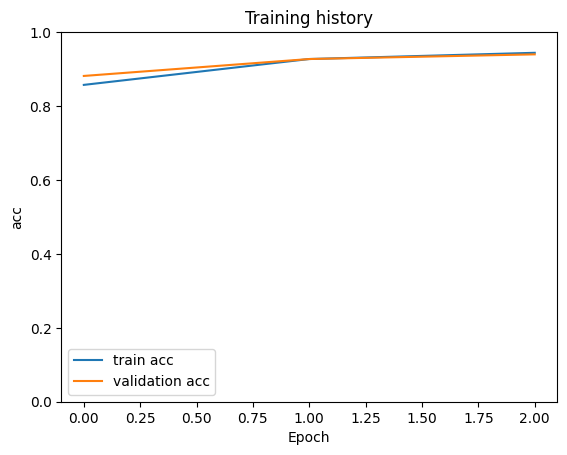

In [80]:
# Plot nilai akurasi data latih dari dictionary history
plt.plot(history['train_acc'], label='train acc')

# Plot nilai akurasi data validasi dari dictionary history
plt.plot(history['val_acc'], label='validation acc')

# Beri judul grafik
plt.title('Training history')

# Beri label sumbu Y
plt.ylabel('acc')

# Beri label sumbu X
plt.xlabel('Epoch')

# Tampilkan legenda untuk membedakan garis train dan validation
plt.legend()

# Batasi skala sumbu Y dari 0 sampai 1 (karena akurasi dalam range 0-1)
plt.ylim([0, 1]);


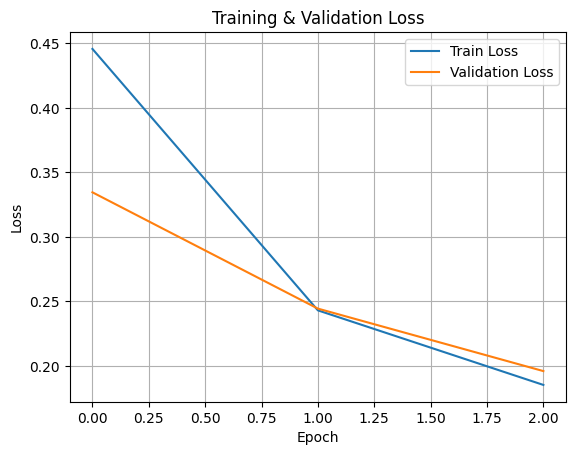

In [81]:
# Plot nilai loss data latih dari dictionary history
plt.plot(history['train_loss'], label='Train Loss')

# Plot nilai loss data validasi dari dictionary history
plt.plot(history['val_loss'], label='Validation Loss')

# Beri judul grafik
plt.title('Training & Validation Loss')

# Beri label sumbu X
plt.xlabel('Epoch')

# Beri label sumbu Y
plt.ylabel('Loss')

# Tampilkan legenda untuk membedakan garis Train Loss dan Validation Loss
plt.legend()

# Aktifkan grid agar garis bantu lebih jelas terbaca di plot
plt.grid(True)

# Tampilkan plot ke layar
plt.show()

In [82]:
# Baca valid_dataset_path (hanya berisi review_text dan category)
val_df = pd.read_csv(valid_dataset_path, sep='\t', names=['review_text', 'category'])

# val_set_full adalah dataframe lengkap validasi yang sudah kamu simpan sebelum training, misalnya:
# val_set_full = val_set.copy()  # pastikan ini ada dan tetap tersimpan dari awal

# Reset index supaya join nanti benar urutannya
val_df = val_df.reset_index(drop=True)
val_set_full = val_set_full.reset_index(drop=True)

# Tambahkan kolom prediksi
val_df['pred'] = list_hyp_val

# Gabungkan kolom jenis dari val_set_full
val_df = pd.concat([val_df, val_set_full['jenis']], axis=1)

# Simpan file lengkap dengan kolom jenis dan prediksi
val_df.to_csv('val_result_with_jenis.csv', index=False)


In [83]:
# Tambahkan ini setelah training selesai
df_history = pd.DataFrame(history)
print(df_history)
df_history.to_csv("training_log.csv", index=False)

   train_acc  train_loss   val_acc  val_loss
0   0.857250    0.445783  0.881430  0.334621
1   0.927223    0.243114  0.927201  0.244464
2   0.944040    0.185311  0.939843  0.196034


### Prediksi Test Set

In [84]:
# Prediksi test set
model.eval()
torch.set_grad_enabled(False)

total_loss, total_correct, total_labels = 0, 0, 0
pred, list_label = [], []

pbar = tqdm(test_loader, leave=True, total=len(test_loader))
for i, batch_data in enumerate(pbar):
    _, batch_hyp, _ = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cuda')
    pred += batch_hyp

100%|██████████| 287/287 [00:04<00:00, 71.61it/s]


In [85]:
# Baca file test data yang berisi review_text dan category saja (hasil preprocessing)
test_df = pd.read_csv(test_dataset_path, sep='\t', names=['review_text', 'category'])

# Pastikan kamu punya test_set_full yang lengkap, misal:
# test_set_full = test_set.copy()

# Reset index supaya penggabungan kolom sesuai baris
test_df = test_df.reset_index(drop=True)
test_set_full = test_set_full.reset_index(drop=True)

# Tambahkan kolom prediksi hasil model
test_df['pred'] = pred

# Gabungkan kolom jenis dari test_set_full
test_df = pd.concat([test_df, test_set_full['jenis']], axis=1)

# Simpan ke file csv baru, dengan kolom jenis dan prediksi
test_df.to_csv('test_result_with_jenis.csv', index=False)


## Test Fine Tuned Model

In [86]:
import torch

text = "ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you"

# Tokenisasi dan ubah ke tensor
subwords = tokenizer.encode(text, return_tensors="pt").to(model.device)

# Dapatkan logits dari model
with torch.no_grad():
    logits = model(subwords)[0]  # Jika model adalah seperti BERTForSequenceClassification

# Ambil prediksi label dan confidence-nya
probabilities = torch.softmax(logits, dim=-1)
confidence, label = torch.max(probabilities, dim=-1)

# Ubah ke Python native types
label = label.item()
confidence = confidence.item() * 100

# Cetak hasil
print(f"Text: {text} | Label: {i2w[label]} ({confidence:.2f}%)")
print(f"Logits: {logits.detach().cpu().numpy()}")

Text: ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you | Label: positif (99.43%)
Logits: [[-1.6344241 -1.3744642  4.3625293]]


In [87]:
import torch

# Teks input
text = "ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you"

# Tokenisasi dan ubah ke tensor
subwords = tokenizer.encode(text, return_tensors="pt").to(model.device)

# Dapatkan logits dari model
with torch.no_grad():
    logits = model(subwords)[0]  # Output logits

# Ubah logits ke probabilitas dengan softmax
probabilities = torch.softmax(logits, dim=-1)

# Ambil prediksi label dan confidence-nya
confidence, label = torch.max(probabilities, dim=-1)

# Ubah ke Python native types
label = label.item()
confidence = confidence.item() * 100

# Konversi probabilitas ke numpy array
probabilities = probabilities.detach().cpu().numpy()

# Cetak hasil
print(f"Text: {text}")
print(f"Probabilitas per kelas: {probabilities}")
print(f"Prediksi: {i2w[label]} ({confidence:.2f}%)")

Text: ih bagus banget sih ini cuma agak pricey saja semoga dibanyakin lagi promonya thank you
Probabilitas per kelas: [[0.0024722  0.00320614 0.9943216 ]]
Prediksi: positif (99.43%)


# **Evaluasi**

In [88]:
# Ambil nilai kolom 'category' dari dataframe val_df sebagai label ground truth untuk data validasi
val_real = val_df.category

# Ambil nilai kolom 'pred' dari dataframe val_df sebagai hasil prediksi model di data validasi
val_pred = val_df.pred

# Ambil nilai kolom 'category' dari dataframe test_df sebagai label ground truth untuk data test
test_real = test_df.category

# Ambil nilai kolom 'pred' dari dataframe test_df sebagai hasil prediksi model di data test
test_pred = test_df.pred

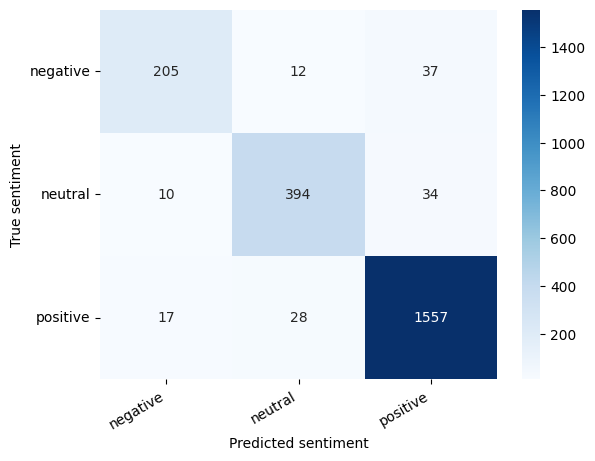

In [89]:
# Fungsi untuk menampilkan confusion matrix dalam bentuk heatmap
def show_confusion_matrix(confusion_matrix):
    # Membuat heatmap menggunakan seaborn, dengan nilai dalam kotak ditampilkan, format integer, dan colormap biru
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    
    # Atur rotasi label sumbu Y (True labels) jadi horizontal (0 derajat)
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    
    # Atur rotasi label sumbu X (Predicted labels) jadi miring 30 derajat ke kanan
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    
    # Beri label sumbu Y
    plt.ylabel('True sentiment')
    
    # Beri label sumbu X
    plt.xlabel('Predicted sentiment')

# Hitung confusion matrix untuk data validasi
cm = confusion_matrix(val_real, val_pred)

# Ubah hasil confusion matrix jadi DataFrame agar bisa diberi label baris dan kolom
df_cm = pd.DataFrame(cm, 
                     index=['negative', 'neutral', 'positive'], 
                     columns=['negative', 'neutral', 'positive'])

# Tampilkan heatmap confusion matrix
show_confusion_matrix(df_cm)

In [90]:
# Cetak laporan klasifikasi yang berisi metrik evaluasi seperti precision, recall, f1-score, dan support 
# untuk masing-masing kelas (negative, neutral, positive)
print(classification_report(val_real, val_pred, target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.88      0.81      0.84       254
     neutral       0.91      0.90      0.90       438
    positive       0.96      0.97      0.96      1602

    accuracy                           0.94      2294
   macro avg       0.92      0.89      0.90      2294
weighted avg       0.94      0.94      0.94      2294



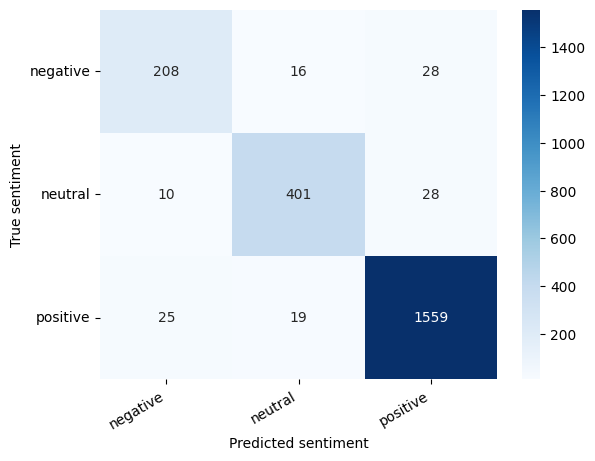

In [91]:
def show_confusion_matrix(confusion_matrix):
  hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
  hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
  hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
  plt.ylabel('True sentiment')
  plt.xlabel('Predicted sentiment');

cm = confusion_matrix(test_real, test_pred)
df_cm = pd.DataFrame(cm, index=['negative', 'neutral', 'positive'], columns=['negative', 'neutral', 'positive'])
show_confusion_matrix(df_cm)

In [92]:
print(classification_report(test_real, test_pred, target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.86      0.83      0.84       252
     neutral       0.92      0.91      0.92       439
    positive       0.97      0.97      0.97      1603

    accuracy                           0.95      2294
   macro avg       0.91      0.90      0.91      2294
weighted avg       0.94      0.95      0.94      2294



# Output Akhir Untuk Kesimpulan Laporan

In [93]:
# Hanya simpan ke file tsv yang input dan label saja (untuk model training)
train_dataa = train_set[['review_text','jenis', 'category']]
val_dataa = val_set[['review_text','jenis', 'category']]
test_dataa = test_set[['review_text','jenis', 'category']]

# Simpan masing-masing ke file Excel terpisah
train_dataa.to_excel('train_set12.xlsx', index=False)
val_dataa.to_excel('val_set12.xlsx', index=False)
test_dataa.to_excel('test_set12.xlsx', index=False)

In [94]:
# Tambahkan kolom baru 'pred' ke dataframe test_dataa, isinya hasil prediksi dari list pred
test_dataa['pred'] = pred

# Simpan dataframe test_dataa ke file Excel dengan nama 'test_set123.xlsx' tanpa menyimpan index baris
test_dataa.to_excel('test_set123.xlsx', index=False)

/tmp/ipykernel_370/2802372408.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_dataa['pred'] = pred


In [95]:
# Menampilkan jumlah kemunculan masing-masing nilai unik dalam kolom 'category' pada dataframe test_dataa
test_dataa['category'].value_counts()

category
positif    1603
netral      439
negatif     252
Name: count, dtype: int64

In [96]:
# Menampilkan jumlah kemunculan masing-masing nilai unik dalam kolom 'pred' pada dataframe test_dataa
test_dataa['pred'].value_counts()

pred
positif    1615
netral      436
negatif     243
Name: count, dtype: int64

In [97]:
import pandas as pd

# Baca file yang sudah ada kolom prediksinya
df = pd.read_excel('test_set123.xlsx')  # Ganti dengan path file kamu jika beda

# Hitung jumlah prediksi untuk setiap jenis dan label
result = df.groupby(['jenis', 'pred']).size().unstack(fill_value=0)

print(result)

pred      negatif  netral  positif
jenis                             
Makeup        130     213      802
Skincare      113     223      813


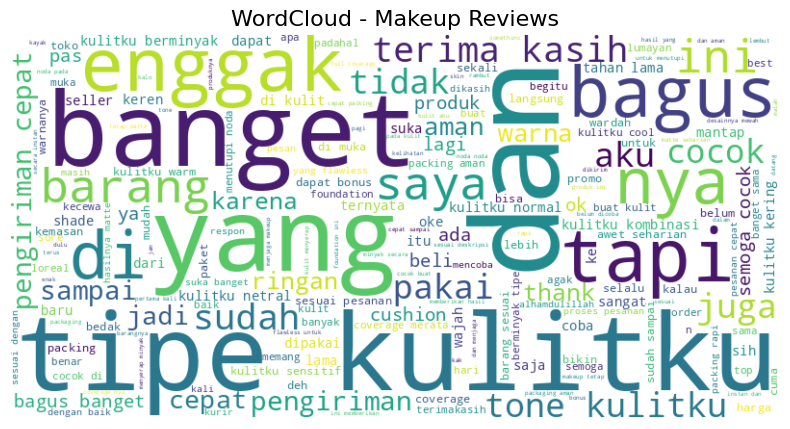

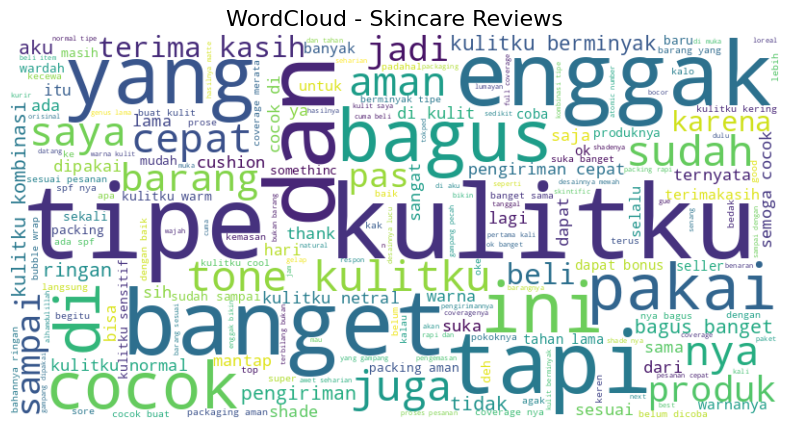

In [98]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Baca dataset
df = pd.read_excel('test_set123.xlsx')  # ganti dengan nama file kamu

# Pastikan semua review_text dalam bentuk string
df['review_text'] = df['review_text'].astype(str)

# Buat fungsi untuk generate wordcloud
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Wordcloud untuk Makeup
makeup_reviews = df[df['jenis'] == 'Makeup']['review_text']
generate_wordcloud(makeup_reviews, 'WordCloud - Makeup Reviews')

# Wordcloud untuk Skincare
skincare_reviews = df[df['jenis'] == 'Skincare']['review_text']
generate_wordcloud(skincare_reviews, 'WordCloud - Skincare Reviews')

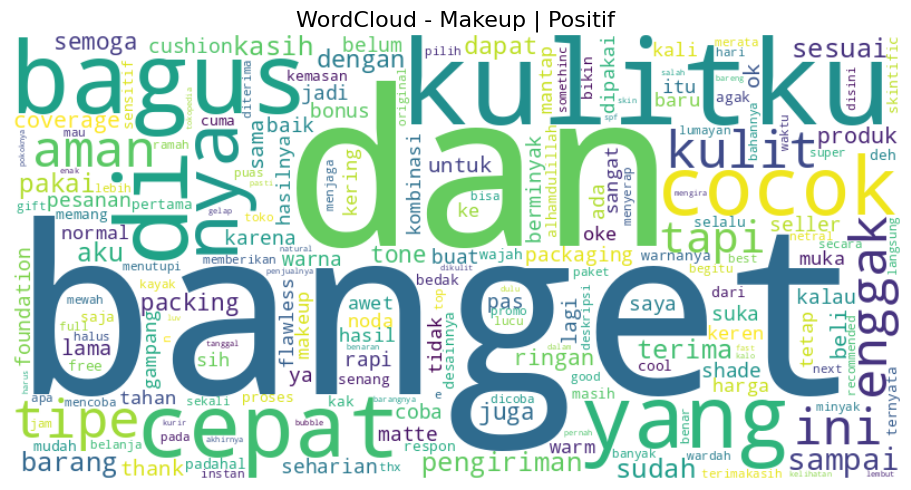

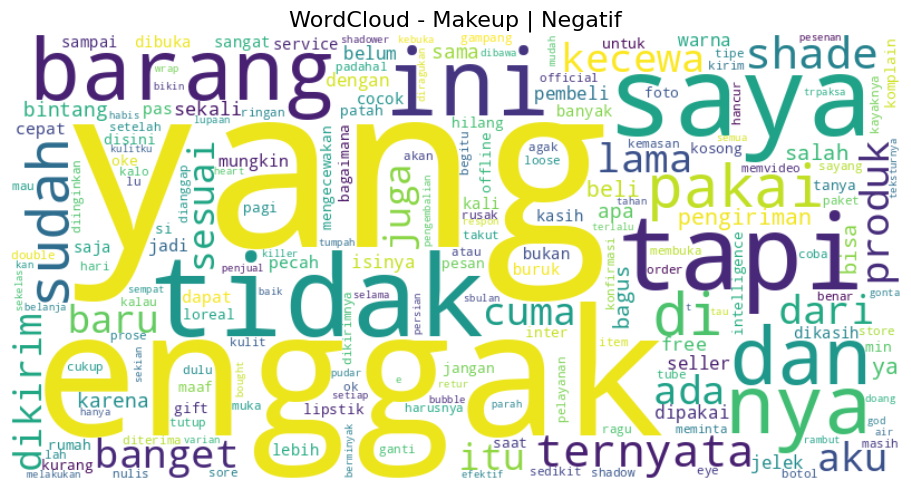

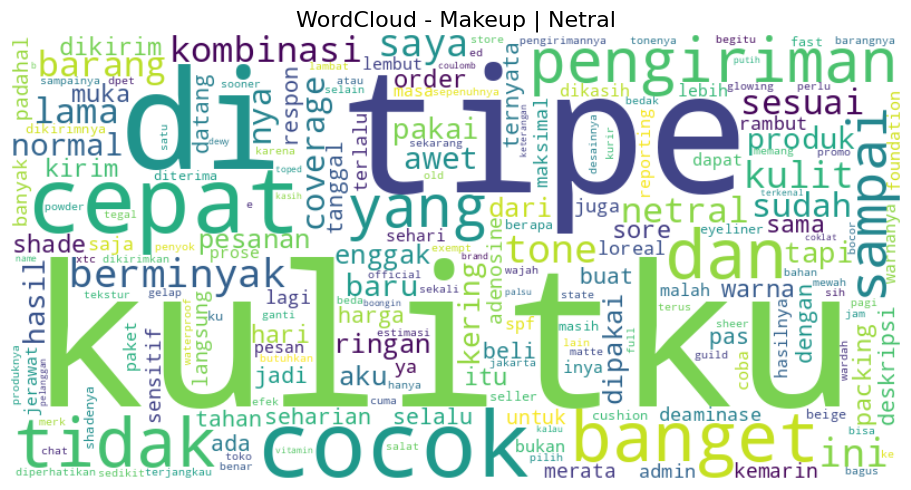

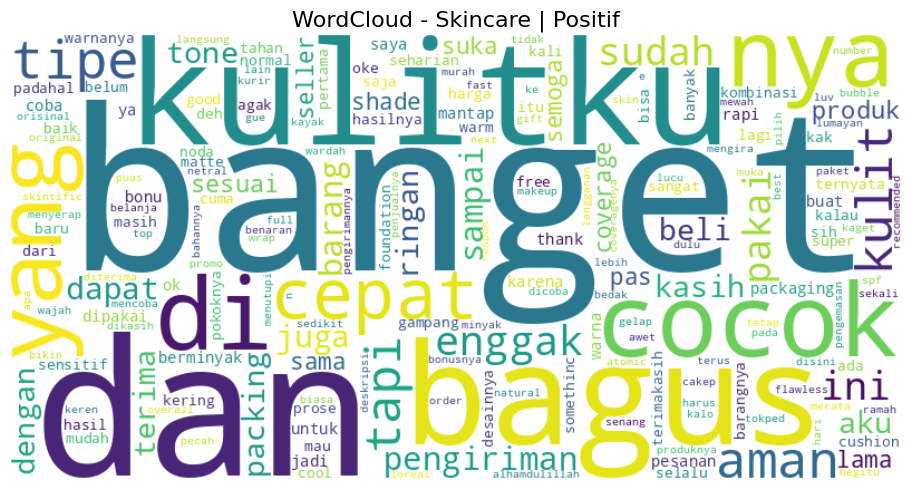

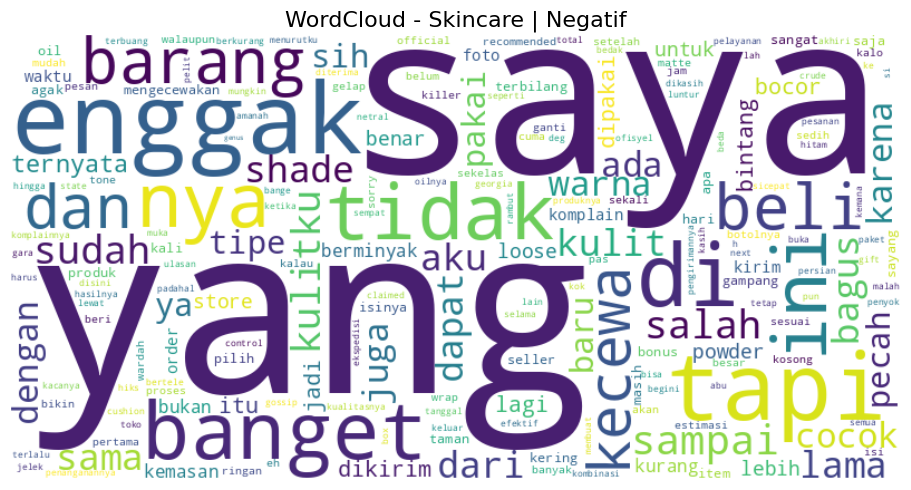

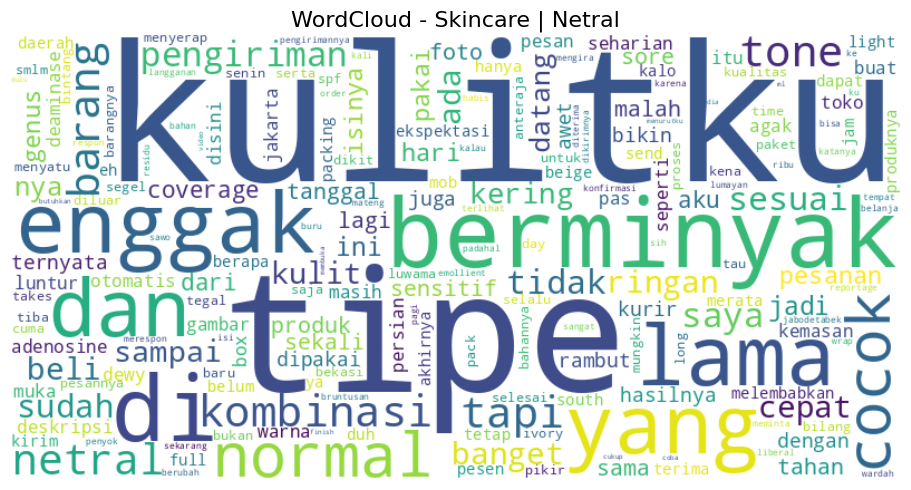

In [99]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Baca file
df = pd.read_excel('test_set123.xlsx')  # Ganti nama file kalau beda

# Pastikan review_text adalah string
df['review_text'] = df['review_text'].astype(str)

# List jenis dan sentimen
jenis_list = df['jenis'].unique()
sentimen_list = df['pred'].unique()

# Loop untuk setiap kombinasi
for jenis in jenis_list:
    for sentimen in sentimen_list:
        subset = df[(df['jenis'] == jenis) & (df['pred'] == sentimen)]

        if not subset.empty:
            text = ' '.join(subset['review_text'])

            wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                max_words=200,
                collocations=False
            ).generate(text)

            plt.figure(figsize=(10, 5))
            plt.imshow(wordcloud, interpolation='bilinear')
            plt.axis('off')
            plt.title(f'WordCloud - {jenis} | {sentimen.capitalize()}', fontsize=16)
            plt.tight_layout()
            plt.show()
